# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Correa Preciado Jonathan Alexi
**Fecha:** 28/06/2026

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [26]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [27]:
# Cargar el dataset car.data
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None, names=col_names)

print('Dimensiones del dataset:', df.shape)
df.head()


Dimensiones del dataset: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta: A


## Parte 2: Análisis Exploratorio de Datos (EDA)

In [28]:
# Explorar información del dataset
print('=== Información del Dataset ===')
df.info()
print('\n=== Estadísticas Descriptivas ===')
df.describe()


=== Información del Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB

=== Estadísticas Descriptivas ===


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [29]:
# Verificar valores únicos por columna
for col in df.columns:
    print(f'{col}: {df[col].unique()}')


buying: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
maint: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
doors: <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
persons: <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
lug_boot: <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
safety: <StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
class: <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


In [30]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\nTotal de valores nulos:', df.isnull().sum().sum())


Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Total de valores nulos: 0


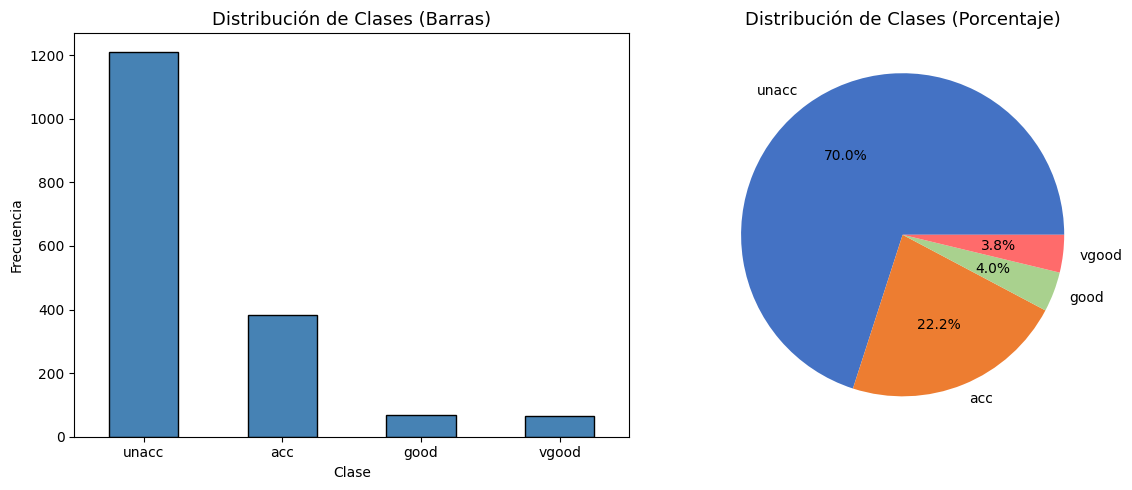


Conteo de clases:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Porcentaje:
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64


In [31]:
# Visualizar la distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
df['class'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Clases (Barras)', fontsize=13)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de pastel
df['class'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#4472C4','#ED7D31','#A9D18E','#FF6B6B'])
axes[1].set_title('Distribución de Clases (Porcentaje)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\nConteo de clases:')
print(df['class'].value_counts())
print('\nPorcentaje:')
print(df['class'].value_counts(normalize=True).round(3) * 100)


### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C


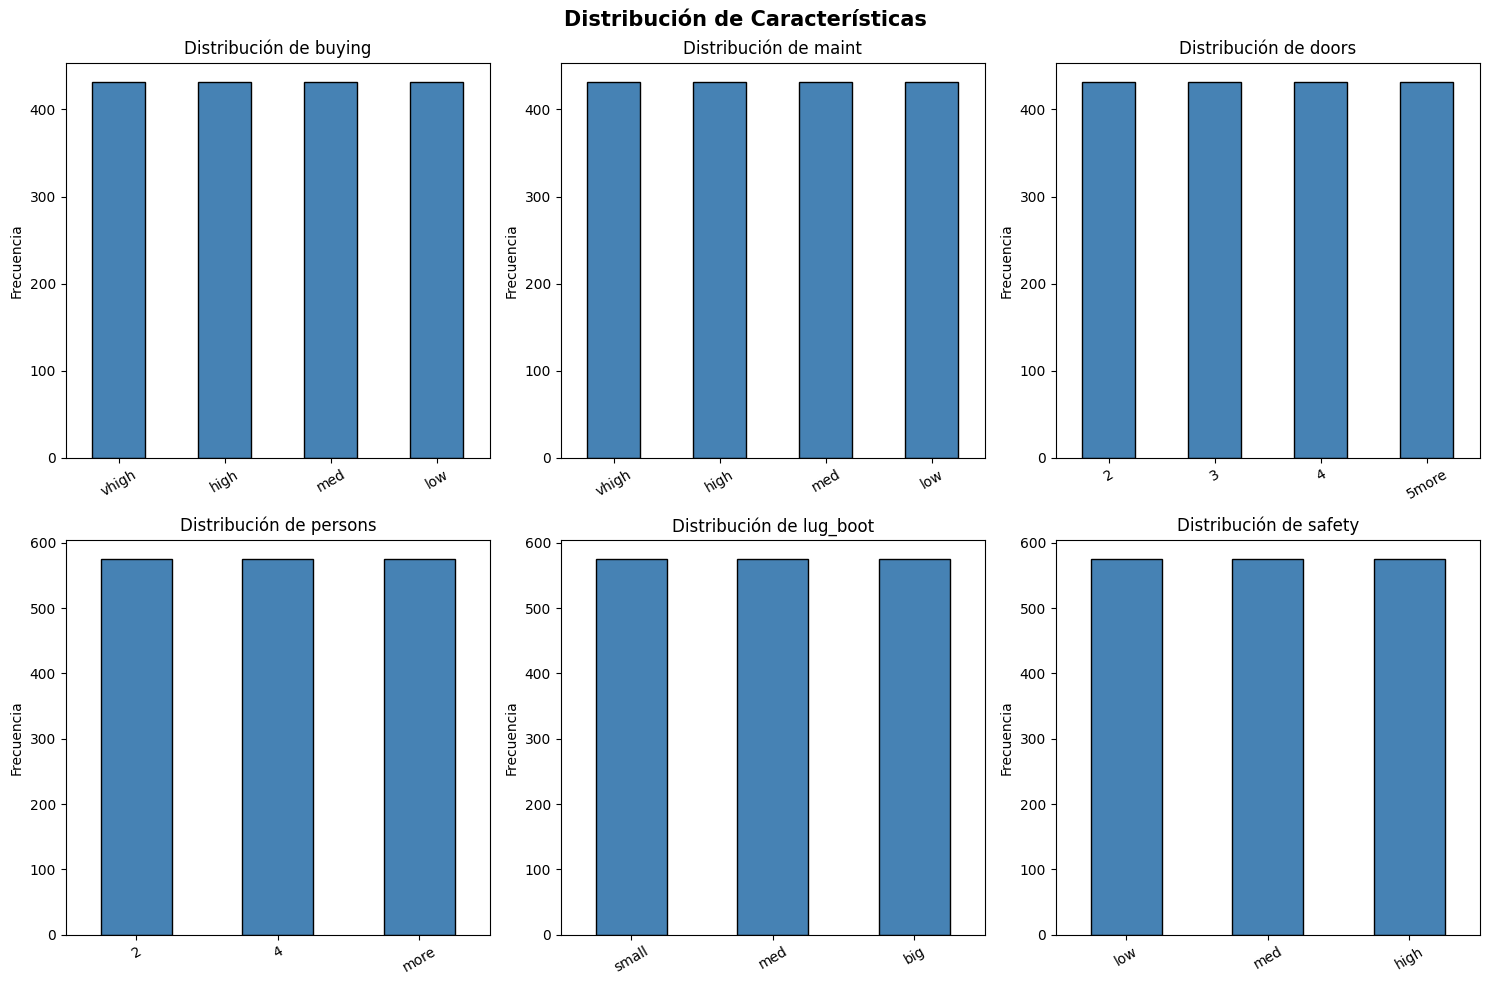

In [32]:
# Visualizar distribución de características
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    df[feature].value_counts().plot(kind='bar', ax=axes[i],
                                     color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {feature}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de Características', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B


## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [33]:
# Aplicar Label Encoding a todas las columnas
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print('DataFrame codificado (primeras filas):')
df_encoded.head()


DataFrame codificado (primeras filas):


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [34]:
# Mostrar el mapeo de etiquetas
print('Mapeo de categorías a valores numéricos:')
print('=' * 50)
for col, le in label_encoders.items():
    mapping = dict(zip(le.classes_, range(len(le.classes_))))
    print(f'{col}: {mapping}')


Mapeo de categorías a valores numéricos:
buying: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
maint: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
doors: {'2': 0, '3': 1, '4': 2, '5more': 3}
persons: {'2': 0, '4': 1, 'more': 2}
lug_boot: {'big': 0, 'med': 1, 'small': 2}
safety: {'high': 0, 'low': 1, 'med': 2}
class: {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B


## Parte 4: División de Datos

In [35]:
# Separar características (X) y variable objetivo (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)
print('\nNombre de características:', list(X.columns))


Forma de X: (1728, 6)
Forma de y: (1728,)

Nombre de características: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [36]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')
print(f'\nProporción: {X_train.shape[0]/len(X)*100:.1f}% entrenamiento | {X_test.shape[0]/len(X)*100:.1f}% prueba')


Tamaño del conjunto de entrenamiento: 1157 muestras
Tamaño del conjunto de prueba: 571 muestras

Proporción: 67.0% entrenamiento | 33.0% prueba


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B


## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [37]:
# Crear y entrenar el modelo con criterio Gini
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)

print('=== Árbol de Decisión - Criterio GINI ===')
print(f'Profundidad del árbol: {clf_gini.get_depth()}')
print(f'Número de hojas: {clf_gini.get_n_leaves()}')


=== Árbol de Decisión - Criterio GINI ===
Profundidad del árbol: 3
Número de hojas: 5


In [38]:
# Realizar predicciones y evaluar - Gini
y_pred_gini = clf_gini.predict(X_test)
y_pred_gini_train = clf_gini.predict(X_train)

acc_gini_test = accuracy_score(y_test, y_pred_gini)
acc_gini_train = accuracy_score(y_train, y_pred_gini_train)

print(f'Precisión en entrenamiento (Gini): {acc_gini_train:.4f} ({acc_gini_train*100:.2f}%)')
print(f'Precisión en prueba (Gini):        {acc_gini_test:.4f} ({acc_gini_test*100:.2f}%)')


Precisión en entrenamiento (Gini): 0.7744 (77.44%)
Precisión en prueba (Gini):        0.7653 (76.53%)


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B


## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [39]:
# Crear y entrenar el modelo con criterio Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)

print('=== Árbol de Decisión - Criterio ENTROPY ===')
print(f'Profundidad del árbol: {clf_entropy.get_depth()}')
print(f'Número de hojas: {clf_entropy.get_n_leaves()}')


=== Árbol de Decisión - Criterio ENTROPY ===
Profundidad del árbol: 3
Número de hojas: 5


In [40]:
# Realizar predicciones y evaluar - Entropy
y_pred_entropy = clf_entropy.predict(X_test)
y_pred_entropy_train = clf_entropy.predict(X_train)

acc_entropy_test = accuracy_score(y_test, y_pred_entropy)
acc_entropy_train = accuracy_score(y_train, y_pred_entropy_train)

print(f'Precisión en entrenamiento (Entropy): {acc_entropy_train:.4f} ({acc_entropy_train*100:.2f}%)')
print(f'Precisión en prueba (Entropy):        {acc_entropy_test:.4f} ({acc_entropy_test*100:.2f}%)')


Precisión en entrenamiento (Entropy): 0.7744 (77.44%)
Precisión en prueba (Entropy):        0.7653 (76.53%)


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [41]:
# Crear tabla comparativa
tabla_comparativa = pd.DataFrame({
    'Criterio': ['Gini Index', 'Entropy'],
    'Precisión Train': [f'{acc_gini_train*100:.2f}%', f'{acc_entropy_train*100:.2f}%'],
    'Precisión Test': [f'{acc_gini_test*100:.2f}%', f'{acc_entropy_test*100:.2f}%'],
    'Profundidad': [clf_gini.get_depth(), clf_entropy.get_depth()],
    'Hojas': [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]
})

print('=== Tabla Comparativa: Gini vs Entropy ===')
print(tabla_comparativa.to_string(index=False))


=== Tabla Comparativa: Gini vs Entropy ===
  Criterio Precisión Train Precisión Test  Profundidad  Hojas
Gini Index          77.44%         76.53%            3      5
   Entropy          77.44%         76.53%            3      5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B


## Parte 8: Matriz de Confusión y Métricas

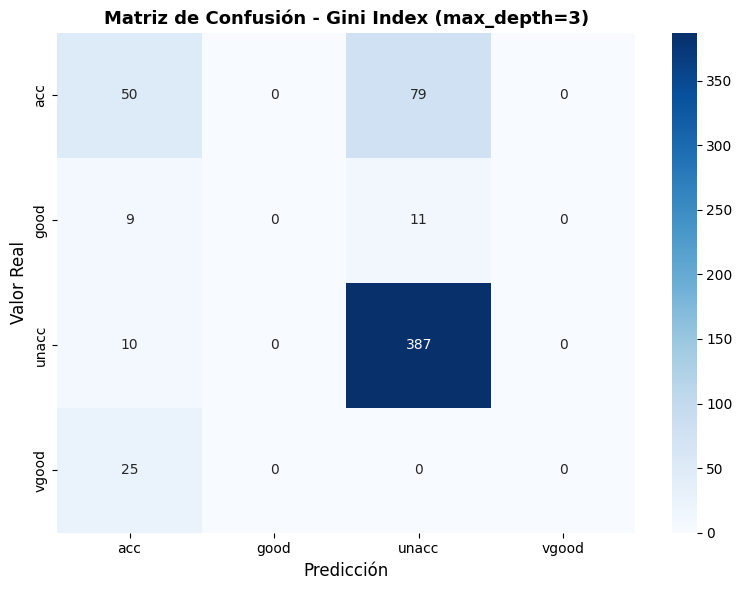

In [42]:
# Calcular y visualizar la matriz de confusión para el modelo Gini
class_names = label_encoders['class'].classes_
cm = confusion_matrix(y_test, y_pred_gini)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión - Gini Index (max_depth=3)', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()


In [43]:
# Imprimir el reporte de clasificación
print('=== Reporte de Clasificación - Gini Index ===')
print(classification_report(y_test, y_pred_gini, target_names=class_names))


=== Reporte de Clasificación - Gini Index ===
              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

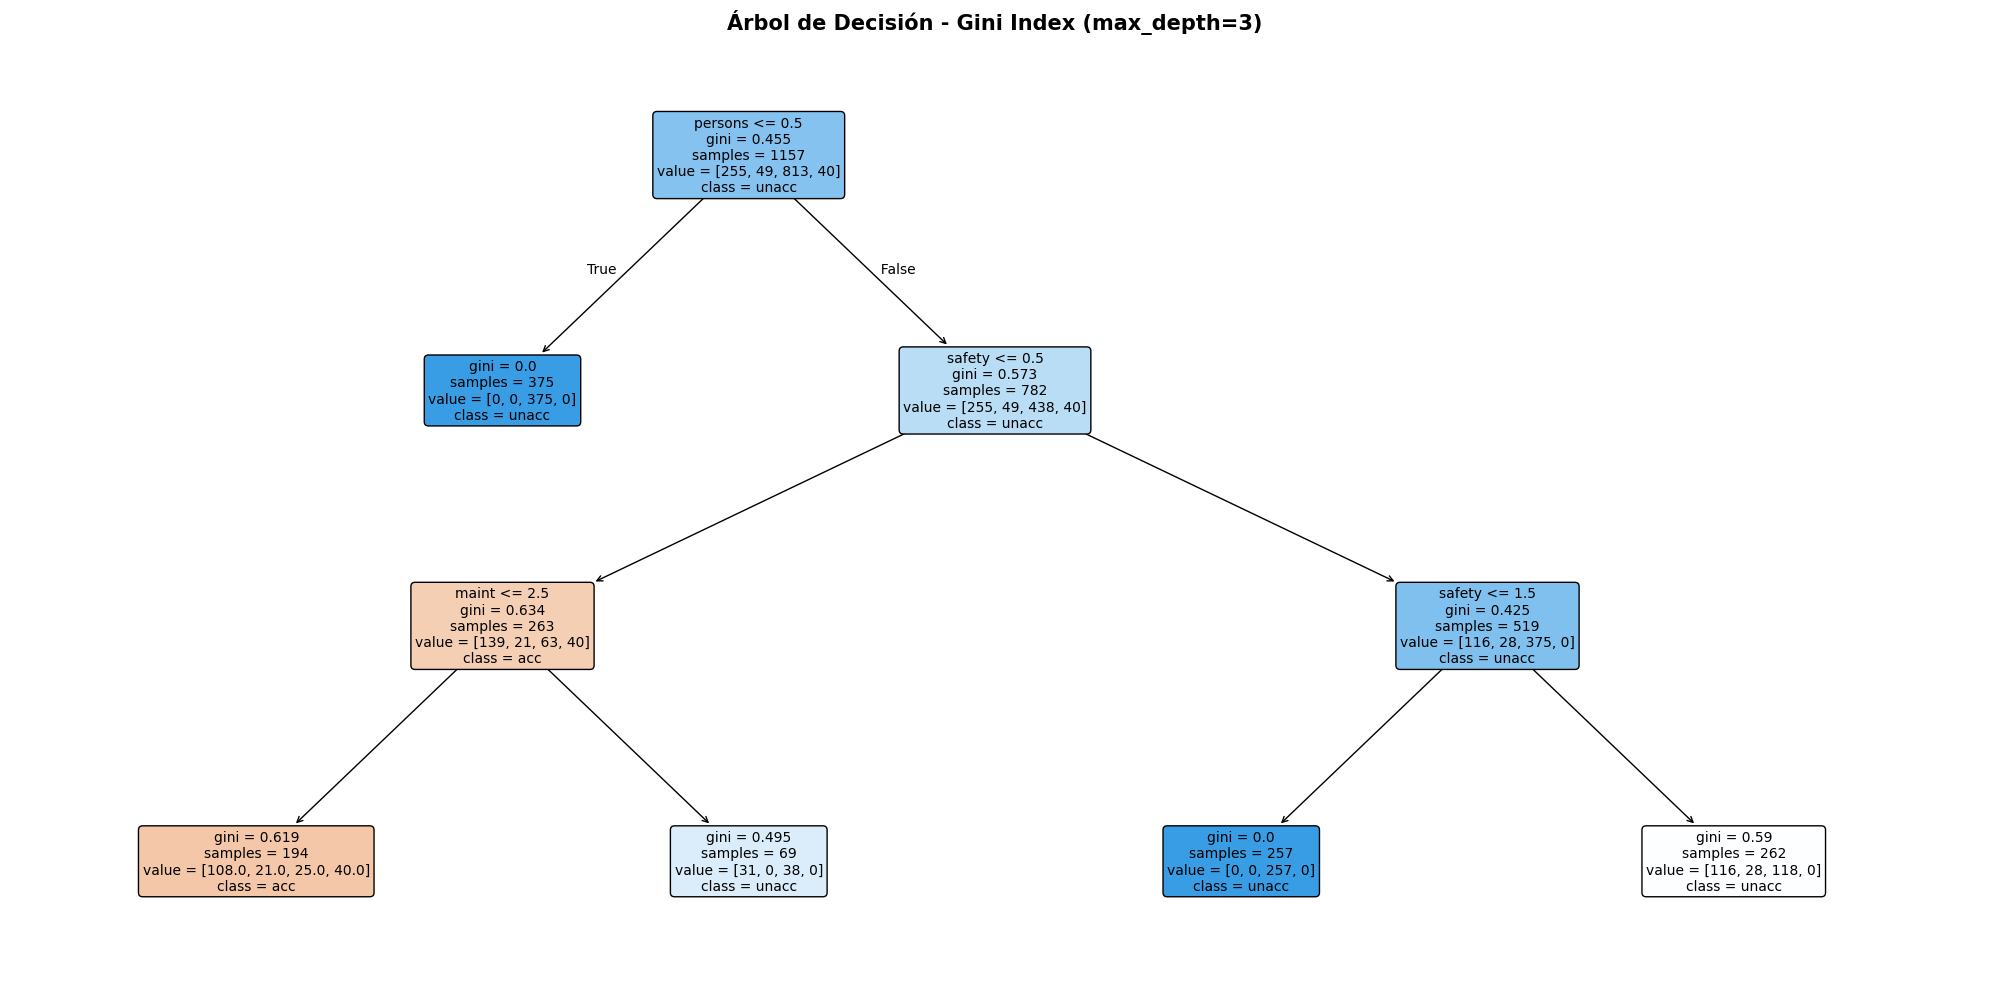

In [44]:
# Visualizar el árbol de decisión con Gini
plt.figure(figsize=(20, 10))
plot_tree(
    clf_gini,
    feature_names=list(X.columns),
    class_names=list(class_names),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión - Gini Index (max_depth=3)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


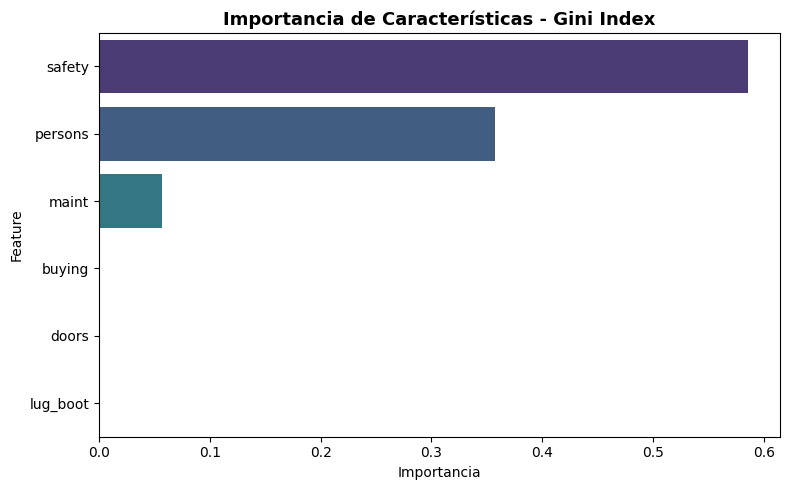


=== Tabla de Importancias ===
 Feature  Importance
  safety    0.585506
 persons    0.357400
   maint    0.057095
  buying    0.000000
   doors    0.000000
lug_boot    0.000000


In [45]:
# Mostrar la importancia de las características
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature',
            palette='viridis')
plt.title('Importancia de Características - Gini Index', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('\n=== Tabla de Importancias ===')
print(feature_importance_df.to_string(index=False))


### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [46]:
# Experimentar con diferentes valores de max_depth
depths = [1, 2, 3, 5, 7, 10, None]
results = []

for depth in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    results.append({
        'max_depth': str(depth),
        'Train Accuracy': f'{train_acc*100:.2f}%',
        'Test Accuracy': f'{test_acc*100:.2f}%',
        'Profundidad Real': clf.get_depth(),
        'Hojas': clf.get_n_leaves()
    })

df_depths = pd.DataFrame(results)
print('=== Efecto de max_depth ===')
print(df_depths.to_string(index=False))


=== Efecto de max_depth ===
max_depth Train Accuracy Test Accuracy  Profundidad Real  Hojas
        1         70.27%        69.53%                 1      2
        2         76.84%        77.06%                 2      3
        3         77.44%        76.53%                 3      5
        5         85.57%        86.51%                 5     13
        7         93.00%        93.52%                 7     28
       10         99.31%        96.15%                10     62
     None        100.00%        96.67%                14     73


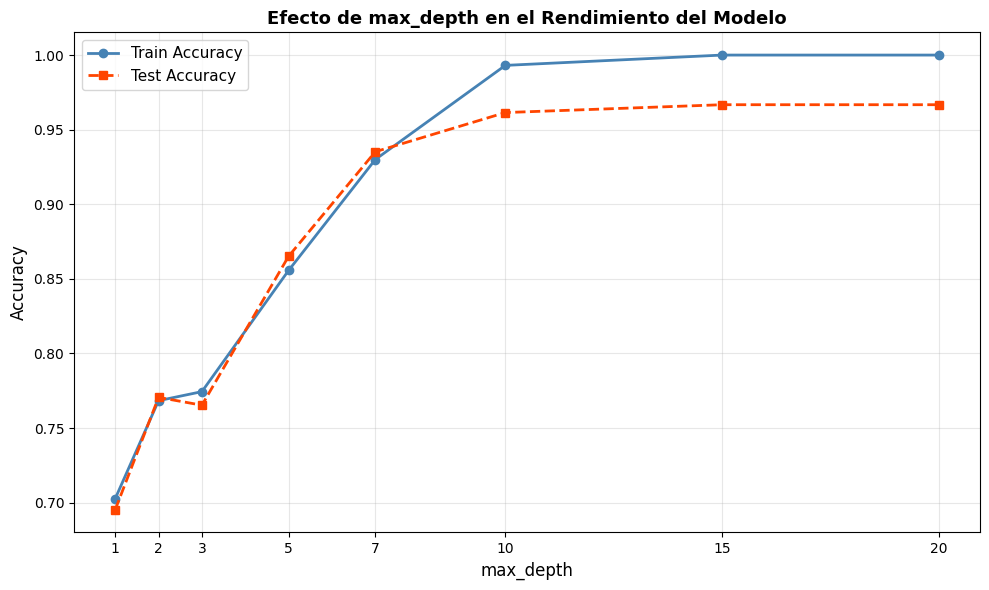

In [47]:
# Visualizar el efecto de max_depth
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores = []

for depth in depths_plot:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_scores, 'o-', label='Train Accuracy', color='steelblue', linewidth=2)
plt.plot(depths_plot, test_scores, 's--', label='Test Accuracy', color='orangered', linewidth=2)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Efecto de max_depth en el Rendimiento del Modelo', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(depths_plot)
plt.tight_layout()
plt.show()


### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C


In [48]:
# Experimentar con min_samples_split
min_samples_list = [2, 5, 10, 20, 50]
results_ms = []

for ms in min_samples_list:
    clf = DecisionTreeClassifier(criterion='gini', min_samples_split=ms, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    results_ms.append({
        'min_samples_split': ms,
        'Train Accuracy': f'{train_acc*100:.2f}%',
        'Test Accuracy': f'{test_acc*100:.2f}%',
        'Profundidad': clf.get_depth(),
        'Hojas': clf.get_n_leaves()
    })

df_ms = pd.DataFrame(results_ms)
print('=== Efecto de min_samples_split (sin límite max_depth) ===')
print(df_ms.to_string(index=False))


=== Efecto de min_samples_split (sin límite max_depth) ===
 min_samples_split Train Accuracy Test Accuracy  Profundidad  Hojas
                 2        100.00%        96.67%           14     73
                 5         99.14%        95.62%           12     62
                10         97.67%        94.22%           11     49
                20         95.33%        93.17%           10     38
                50         89.11%        88.62%            8     19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B


## Parte 11: Modelo Final Optimizado

In [49]:
# Entrenar modelo final con los mejores hiperparámetros
clf_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_split=5,
    random_state=42
)
clf_final.fit(X_train, y_train)

y_pred_final = clf_final.predict(X_test)
acc_final_train = accuracy_score(y_train, clf_final.predict(X_train))
acc_final_test = accuracy_score(y_test, y_pred_final)

print('=== Modelo Final Optimizado ===')
print(f'Hiperparámetros: criterion=gini, max_depth=7, min_samples_split=5')
print(f'Precisión en entrenamiento: {acc_final_train*100:.2f}%')
print(f'Precisión en prueba:        {acc_final_test*100:.2f}%')
print(f'Profundidad del árbol: {clf_final.get_depth()}')
print(f'Número de hojas: {clf_final.get_n_leaves()}')


=== Modelo Final Optimizado ===
Hiperparámetros: criterion=gini, max_depth=7, min_samples_split=5
Precisión en entrenamiento: 92.83%
Precisión en prueba:        93.35%
Profundidad del árbol: 7
Número de hojas: 27


=== Reporte de Clasificación - Modelo Final Optimizado ===
              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



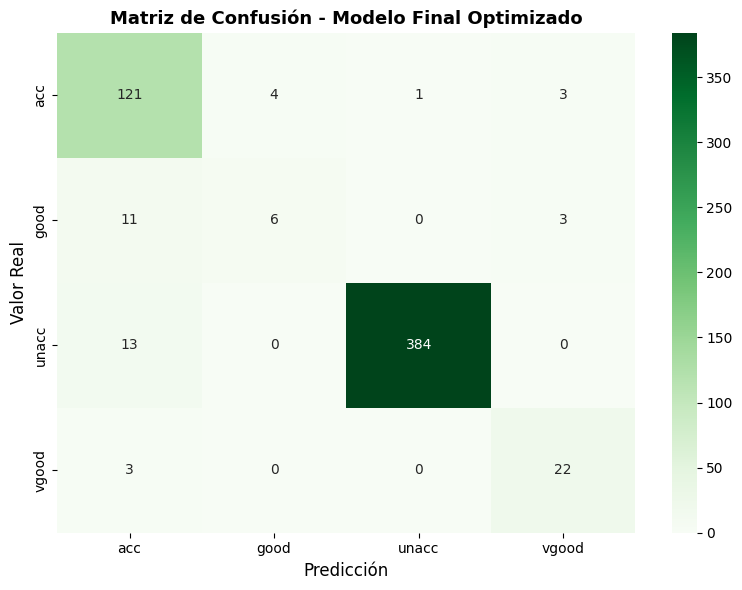

In [50]:
# Reporte de clasificación final
print('=== Reporte de Clasificación - Modelo Final Optimizado ===')
print(classification_report(y_test, y_pred_final, target_names=class_names))

# Matriz de confusión del modelo final
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo Final Optimizado', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()


### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B


### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C
